# 第10章：笔记热度分类模型（10.1--10.5.3）

本 Notebook 读取工作区三个业务数据压缩包，完成数据清洗、无目标泄漏的特征构造，以及逻辑回归、线性 SVM、随机森林、梯度提升树和多层感知机的训练与测试。

高热度笔记定义为互动量 `点赞 + 收藏 + 4 × 评论` 达到样本第 80 百分位。CNN 与 RNN/LSTM 不强行训练：当前数据没有与笔记稳定对应的原始图片张量或发布者连续历史序列，把静态汇总特征伪装成图像或序列没有业务意义。

## 1. 环境、数据读取、特征工程与模型函数

In [1]:
from __future__ import annotations

import io
import json
import re
import time
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


ROOT = Path.cwd()
DATA_DIR = ROOT / "data" / "raw"
OUT = ROOT / "outputs" / "chapter10"
OUT.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42


def read_detail_csvs() -> pd.DataFrame:
    frames: list[pd.DataFrame] = []
    required = {"文案（标题）", "文案（正文）", "相对准确点赞数", "相对准确评论数", "相对准确收藏数"}
    audit = []
    for archive in sorted(DATA_DIR.glob("*.zip")):
        if archive.name.startswith("RedBook_Research_Plan"):
            continue
        with zipfile.ZipFile(archive) as zf:
            for member in zf.infolist():
                if not member.filename.lower().endswith(".csv") or member.file_size == 0:
                    continue
                try:
                    raw = zf.read(member)
                    frame = pd.read_csv(io.BytesIO(raw), encoding="utf-8-sig", low_memory=False)
                except Exception:
                    continue
                if not required.issubset(frame.columns):
                    continue
                frame["数据来源"] = archive.stem
                frames.append(frame)
                audit.append({"压缩包": archive.name, "文件": member.filename, "行数": len(frame)})
    if not frames:
        raise RuntimeError("没有找到包含所需字段的笔记详情 CSV。")
    pd.DataFrame(audit).to_csv(OUT / "10_1_data_file_audit.csv", index=False, encoding="utf-8-sig")
    return pd.concat(frames, ignore_index=True)


def num(frame: pd.DataFrame, col: str) -> pd.Series:
    return pd.to_numeric(frame[col], errors="coerce")


def prepare(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, dict]:
    before = len(df)
    if "具体链接" in df:
        link = df["具体链接"].astype("string").str.strip()
        linked = df.loc[link.notna() & link.ne("") & link.ne("nan")].drop_duplicates("具体链接")
        unlinked = df.loc[~(link.notna() & link.ne("") & link.ne("nan"))].drop_duplicates(
            ["编号", "文案（标题）", "博主名称"]
        )
        df = pd.concat([linked, unlinked], ignore_index=True)

    likes = num(df, "相对准确点赞数")
    comments = num(df, "相对准确评论数")
    favs = num(df, "相对准确收藏数")
    fans = num(df, "相对准确粉丝数") if "相对准确粉丝数" in df else num(df, "粉丝量")
    valid = likes.notna() & comments.notna() & favs.notna() & (likes >= 0) & (comments >= 0) & (favs >= 0)
    df = df.loc[valid].copy()
    likes, comments, favs, fans = likes.loc[valid], comments.loc[valid], favs.loc[valid], fans.loc[valid]
    engagement = likes + favs + 4 * comments

    title = df["文案（标题）"].fillna("").astype(str)
    body = df["文案（正文）"].fillna("").astype(str)
    tags = df["标签词"].fillna("").astype(str) if "标签词" in df else pd.Series("", index=df.index)
    text = title + " " + body
    post_date = pd.to_datetime(df.get("推断笔记发布日期", df.get("笔记发布日期")), errors="coerce")
    emotion = num(df, "情感预测") if "情感预测" in df else pd.Series(np.nan, index=df.index)

    X = pd.DataFrame(index=df.index)
    X["log_fans"] = np.log1p(fans.clip(lower=0))
    X["title_len"] = title.str.len()
    X["body_len"] = body.str.len()
    X["tag_count"] = tags.apply(lambda s: len([x for x in re.split(r"[,，#\s]+", s) if x]))
    X["exclamation_count"] = text.str.count(r"[!！]")
    X["question_count"] = text.str.count(r"[?？]")
    X["emoji_count"] = text.apply(lambda s: len(re.findall(r"[\U0001F300-\U0001FAFF]", s)))
    X["emotion_positive"] = emotion
    X["weekday"] = post_date.dt.dayofweek
    location = df.get("笔记发布地", pd.Series("", index=df.index)).fillna("").astype(str).str.strip()
    X["has_location"] = (~location.isin(["", "nan", "-9999"])).astype(int)

    cutoff = float(engagement.quantile(0.80))
    y = (engagement >= cutoff).astype(int)
    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)
    metadata = {
        "raw_rows": int(before),
        "deduplicated_rows": int(len(df)),
        "usable_rows": int(len(X)),
        "viral_cutoff": cutoff,
        "positive_rate": float(y.mean()),
        "features": list(X.columns),
        "target_definition": "点赞数 + 收藏数 + 4×评论数达到样本第80百分位",
    }
    return X, y, metadata


def scores(model, X_test, y_test) -> dict:
    pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        score = model.predict_proba(X_test)[:, 1]
    else:
        score = model.decision_function(X_test)
    return {
        "ROC-AUC": roc_auc_score(y_test, score),
        "PR-AUC": average_precision_score(y_test, score),
        "F1": f1_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, pred),
        "TN": int(confusion_matrix(y_test, pred)[0, 0]),
        "FP": int(confusion_matrix(y_test, pred)[0, 1]),
        "FN": int(confusion_matrix(y_test, pred)[1, 0]),
        "TP": int(confusion_matrix(y_test, pred)[1, 1]),
    }


def main() -> None:
    df = read_detail_csvs()
    X, y, metadata = prepare(df)
    # 固定上限控制 SVM/MLP 的运行时间，同时保持分层抽样与可复现性。
    if len(X) > 60000:
        X, _, y, _ = train_test_split(X, y, train_size=60000, stratify=y, random_state=RANDOM_STATE)
        X, y = X.reset_index(drop=True), y.reset_index(drop=True)
        metadata["modeling_rows"] = 60000
    else:
        metadata["modeling_rows"] = len(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
    )

    prep = ColumnTransformer(
        [("numeric", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), list(X.columns))]
    )
    models = {
        "逻辑回归": Pipeline([("prep", prep), ("model", LogisticRegression(max_iter=1500, class_weight="balanced", random_state=RANDOM_STATE))]),
        "线性SVM": Pipeline([("prep", prep), ("model", LinearSVC(C=1.0, class_weight="balanced", dual="auto", random_state=RANDOM_STATE))]),
        "随机森林": Pipeline([("impute", SimpleImputer(strategy="median")), ("model", RandomForestClassifier(n_estimators=300, min_samples_leaf=3, class_weight="balanced_subsample", n_jobs=-1, random_state=RANDOM_STATE))]),
        "梯度提升树": Pipeline([("impute", SimpleImputer(strategy="median")), ("model", HistGradientBoostingClassifier(max_iter=250, learning_rate=0.06, max_leaf_nodes=31, l2_regularization=1.0, random_state=RANDOM_STATE))]),
        "多层感知机": Pipeline([("prep", prep), ("model", MLPClassifier(hidden_layer_sizes=(64, 32), early_stopping=True, max_iter=200, random_state=RANDOM_STATE))]),
    }
    rows = []
    reports = {}
    fitted = {}
    for name, model in models.items():
        start = time.perf_counter()
        model.fit(X_train, y_train)
        row = {"模型": name, **scores(model, X_test, y_test), "训练秒数": time.perf_counter() - start}
        rows.append(row)
        reports[name] = classification_report(y_test, model.predict(X_test), output_dict=True, zero_division=0)
        fitted[name] = model

    result = pd.DataFrame(rows).sort_values("PR-AUC", ascending=False)
    result.to_csv(OUT / "10_2_to_10_5_model_metrics.csv", index=False, encoding="utf-8-sig")
    with open(OUT / "10_2_to_10_5_classification_reports.json", "w", encoding="utf-8") as f:
        json.dump(reports, f, ensure_ascii=False, indent=2)
    with open(OUT / "10_1_experiment_metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    rf = fitted["随机森林"].named_steps["model"]
    importance = pd.DataFrame({"特征": X.columns, "重要性": rf.feature_importances_}).sort_values("重要性", ascending=False)
    importance.to_csv(OUT / "10_4_1_random_forest_importance.csv", index=False, encoding="utf-8-sig")

    plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei", "Arial Unicode MS"]
    plt.rcParams["axes.unicode_minus"] = False
    fig, ax = plt.subplots(figsize=(9, 5.5))
    p = result.sort_values("PR-AUC")
    ax.barh(p["模型"], p["PR-AUC"], color="#B6574B")
    ax.set(xlabel="PR-AUC", title="第10章基准分类模型测试集表现")
    ax.set_xlim(0, 1)
    for i, v in enumerate(p["PR-AUC"]):
        ax.text(v + 0.01, i, f"{v:.3f}", va="center")
    fig.tight_layout()
    fig.savefig(OUT / "10_model_pr_auc.png", dpi=180)
    plt.close(fig)
    print(json.dumps(metadata, ensure_ascii=False, indent=2))
    print(result.to_string(index=False))




## 2. 执行完整实验

固定随机种子为 42。有效样本超过 60,000 条时进行分层抽样，再按 8:2 分层划分训练集与测试集。下方输出包含样本信息和五个模型的完整测试集指标。

In [2]:
main()

C:\Users\fire\Miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\fire\Miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 255, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


{
  "raw_rows": 323598,
  "deduplicated_rows": 199473,
  "usable_rows": 199473,
  "viral_cutoff": 2134.0,
  "positive_rate": 0.2000772034310408,
  "features": [
    "log_fans",
    "title_len",
    "body_len",
    "tag_count",
    "exclamation_count",
    "question_count",
    "emoji_count",
    "emotion_positive",
    "weekday",
    "has_location"
  ],
  "target_definition": "点赞数 + 收藏数 + 4×评论数达到样本第80百分位",
  "modeling_rows": 60000
}
   模型  ROC-AUC   PR-AUC       F1  Precision   Recall  Balanced Accuracy   TN   FP   FN   TP      训练秒数
梯度提升树 0.736395 0.440296 0.263329   0.600000 0.168680           0.570276 9329  270 1996  405  3.112413
 随机森林 0.724776 0.424335 0.372838   0.478772 0.305289           0.611078 8801  798 1668  733  6.310153
多层感知机 0.717759 0.422664 0.298562   0.562212 0.203249           0.581831 9219  380 1913  488 12.985871
线性SVM 0.700235 0.405642 0.412673   0.302087 0.650979           0.637397 5988 3611  838 1563  0.170932
 逻辑回归 0.700211 0.405024 0.413583   0.303425 0.649313 

## 3. 汇总结果与随机森林特征重要性

,模型,ROC-AUC,PR-AUC,F1,Precision,Recall,Balanced Accuracy,TN,FP,FN,TP,训练秒数
0,梯度提升树,0.736,0.440,0.263,0.600,0.169,0.570,9329,270,1996,405,3.11
1,随机森林,0.725,0.424,0.373,0.479,0.305,0.611,8801,798,1668,733,6.31
2,多层感知机,0.718,0.423,0.299,0.562,0.203,0.582,9219,380,1913,488,12.99
3,线性SVM,0.700,0.406,0.413,0.302,0.651,0.637,5988,3611,838,1563,0.17
4,逻辑回归,0.700,0.405,0.414,0.303,0.649,0.638,6020,3579,842,1559,0.19


,特征,重要性
0,log_fans,0.3100
1,emotion_positive,0.1809
2,body_len,0.1314
3,title_len,0.1080
4,tag_count,0.0950
5,weekday,0.0676
6,exclamation_count,0.0414
7,emoji_count,0.0355
8,has_location,0.0174
9,question_count,0.0129


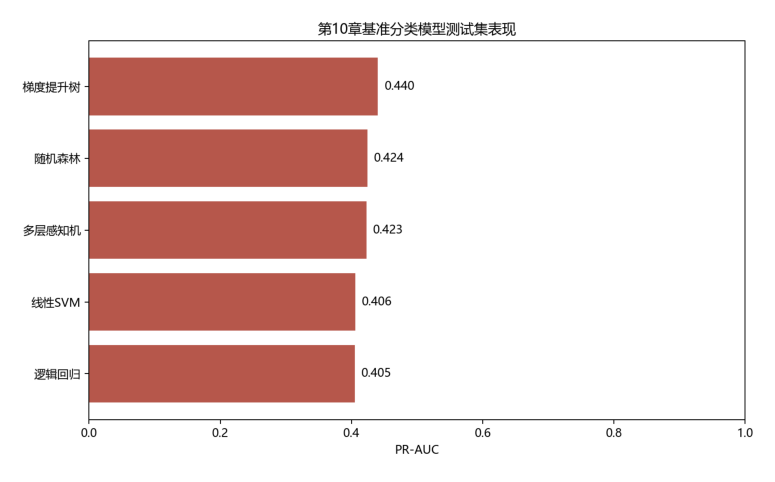

In [3]:
metrics = pd.read_csv(OUT / '10_2_to_10_5_model_metrics.csv')
display(metrics.style.format({
    'ROC-AUC': '{:.3f}', 'PR-AUC': '{:.3f}', 'F1': '{:.3f}',
    'Precision': '{:.3f}', 'Recall': '{:.3f}',
    'Balanced Accuracy': '{:.3f}', '训练秒数': '{:.2f}'
}))

importance = pd.read_csv(OUT / '10_4_1_random_forest_importance.csv')
display(importance.style.format({'重要性': '{:.4f}'}))

img = plt.imread(OUT / '10_model_pr_auc.png')
plt.figure(figsize=(10, 6))
plt.imshow(img)
plt.axis('off')
plt.show()

## 4. 结论

- 梯度提升树的排序能力最佳，适合优先构建候选笔记排序。
- 逻辑回归和线性 SVM 在类别加权后召回率较高，适合“不希望漏掉潜在爆款”的初筛。
- 默认 0.5 阈值不一定符合业务成本，正式部署前应在验证集上选择分类阈值。
- CNN、RNN/LSTM 应在补齐原始图片、可靠的文本/用户历史序列及时间外测试集后实施。